Notebook ini berfokus pada persiapan dataset pertambangan yang telah dibersihkan untuk pemodelan dengan menangani nilai yang hilang, menghapus outlier, membuat fitur baru, dan melakukan pembagian serta scaling data.

## Import Library

In [22]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")


## Loading and Exploring the Cleaned Dataset

Let's load the cleaned data from the previous step.

In [23]:
# Load the cleaned data
df = pd.read_csv('../data/interim/silica_data_cleaned.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Dataset shape: (736282, 24)

First few rows:


,datetime,%_iron_feed,%_silica_feed,starch_flow,amina_flow,ore_pulp_flow,ore_pulp_ph,ore_pulp_density,flotation_column_01_air_flow,flotation_column_02_air_flow,...,flotation_column_07_air_flow,flotation_column_01_level,flotation_column_02_level,flotation_column_03_level,flotation_column_04_level,flotation_column_05_level,flotation_column_06_level,flotation_column_07_level,%_iron_concentrate,%_silica_concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


Terlihat bahwa data sudah dibersihkan, namun ada yang janggal dengan kolom datetime

In [24]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736282 entries, 0 to 736281
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   datetime                      736282 non-null  object 
 1   %_iron_feed                   736282 non-null  float64
 2   %_silica_feed                 736282 non-null  float64
 3   starch_flow                   736282 non-null  float64
 4   amina_flow                    736282 non-null  float64
 5   ore_pulp_flow                 736282 non-null  float64
 6   ore_pulp_ph                   736282 non-null  float64
 7   ore_pulp_density              736282 non-null  float64
 8   flotation_column_01_air_flow  736282 non-null  float64
 9   flotation_column_02_air_flow  736282 non-null  float64
 10  flotation_column_03_air_flow  736282 non-null  float64
 11  flotation_column_04_air_flow  736282 non-null  float64
 12  flotation_column_05_air_flow  736282 non-nul

Kolom datetime kembali berubah ke tipe data object mungkin karena disimpan ke csv sebelumnya

In [25]:
# Verify datetime column is in correct format
df['datetime'] = pd.to_datetime(df['datetime'])

In [26]:
target_column = '%_silica_concentrate'

In [27]:
print(f"Target variable: {target_column}")
print(f"Target variable statistics: \n{df[target_column].describe()}")
print("\n")

Target variable: %_silica_concentrate
Target variable statistics: 
count    736282.000000
mean          2.327270
std           1.125616
min           0.600000
25%           1.440000
50%           2.000000
75%           3.010000
max           5.530000
Name: %_silica_concentrate, dtype: float64




## Outliers Handling

Outlier statistik pada variabel target diidentifikasi dan dihapus menggunakan metode Interquartile Range (IQR):
- Menghitung kuartil (Q1, Q3) dan menghitung IQR = Q3-Q1
- Menentukan batas outlier pada Q1-1.5×IQR dan Q3+1.5×IQR
- Memvisualisasikan distribusi dengan penanda batas
- Menyaring observasi yang berada di luar batas-batas tersebut

Number of outliers in target variable: 4757
Outlier boundaries: Lower = -0.9149999999999996, Upper = 5.364999999999999


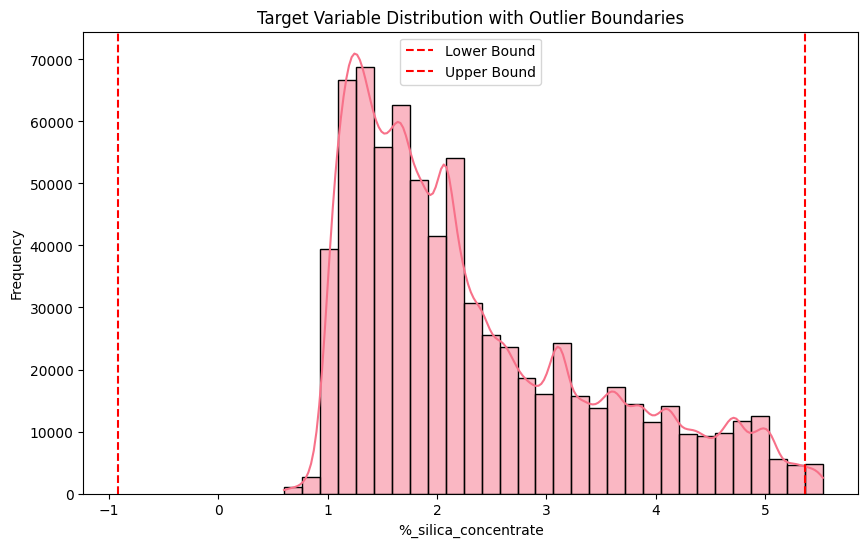

Dataset shape after removing outliers: (731525, 24)


In [28]:
# Check for outliers in target variable using IQR method
Q1 = df[target_column].quantile(0.25)
Q3 = df[target_column].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[target_column] < lower_bound) | (df[target_column] > upper_bound)]
print(f"Number of outliers in target variable: {len(outliers)}")
print(f"Outlier boundaries: Lower = {lower_bound}, Upper = {upper_bound}")

# Visualize target variable with outlier boundaries
plt.figure(figsize=(10, 6))
sns.histplot(df[target_column], bins=30, kde=True)
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')
plt.title('Target Variable Distribution with Outlier Boundaries')
plt.xlabel(target_column)
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Remove outliers from target variable
df = df[(df[target_column] >= lower_bound) & (df[target_column] <= upper_bound)]
print(f"Dataset shape after removing outliers: {df.shape}")

Key Insight(s) tahap Outlier Handling:
- Metode IQR (Interquartile Range) berhasil mengidentifikasi nilai-nilai ekstrem pada variabel target (%_silica_concentrate) dengan menghitung batas bawah (-0.91) dan batas atas (5.36).
- Terdeteksi sekitar 4.757 data outlier (sekitar 0.65% dari keseluruhan dataset) yang mayoritas berada di sisi atas distribusi (>5.36%), mengindikasikan kondisi proses flotasi yang kurang efisien.
- Penghapusan outlier meningkatkan kehandalan model dengan mengurangi pengaruh nilai-nilai ekstrem yang dapat menyebabkan bias dalam pembelajaran algoritma.
- Distribusi data setelah penghapusan outlier menjadi lebih terpusat dan representatif terhadap kondisi operasional normal, yang penting dalam konteks pemodelan prediktif untuk proses industri.
- Penghapusan outlier ini dilakukan sebagai fokus model pada kondisi operasional normal, bukan pada kondisi kegagalan atau gangguan proses yang jarang terjadi.

## Feature Engineering 

Langkah penting ini membuat fitur baru yang informatif yang dapat membantu mengungkap hubungan yang kompleks:
- Mengidentifikasi fitur dengan korelasi kuat terhadap variabel target
- Menghasilkan fitur rasio untuk menangkap hubungan proporsional antar variabel
- Membuat fitur interaksi (perkalian) untuk memodelkan efek gabungan
- Menambahkan suku polinomial untuk menangkap hubungan non-linear
- Menghitung agregasi statistik (mean, std, range) untuk kelompok sensor yang terkait

Top correlations with target variable:
%_silica_concentrate            1.000000
amina_flow                      0.149601
%_silica_feed                   0.067934
ore_pulp_density                0.042666
flotation_column_02_level       0.036838
flotation_column_01_level       0.018013
flotation_column_03_level       0.017053
ore_pulp_flow                   0.010717
flotation_column_05_air_flow   -0.007338
flotation_column_04_air_flow   -0.013684
Name: %_silica_concentrate, dtype: float64

Bottom correlations with target variable:
flotation_column_07_air_flow   -0.080983
flotation_column_06_level      -0.094972
flotation_column_07_level      -0.135414
flotation_column_04_level      -0.144623
ore_pulp_ph                    -0.157531
flotation_column_05_level      -0.163324
flotation_column_02_air_flow   -0.174987
flotation_column_01_air_flow   -0.226938
flotation_column_03_air_flow   -0.227156
%_iron_concentrate             -0.798338
Name: %_silica_concentrate, dtype: float64




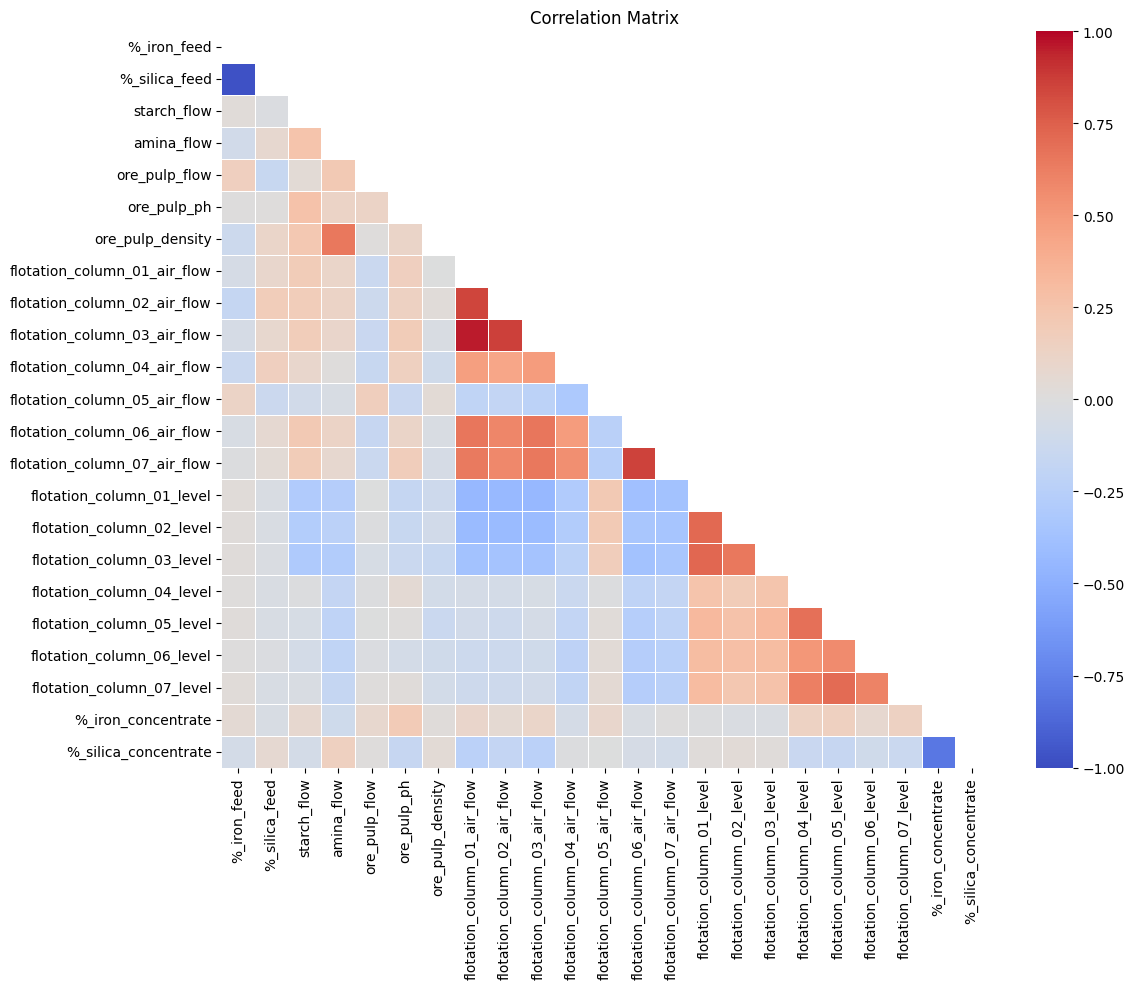

Using top correlated features for engineering: ['%_iron_concentrate', 'flotation_column_03_air_flow', 'flotation_column_01_air_flow', 'flotation_column_02_air_flow', 'flotation_column_05_level']


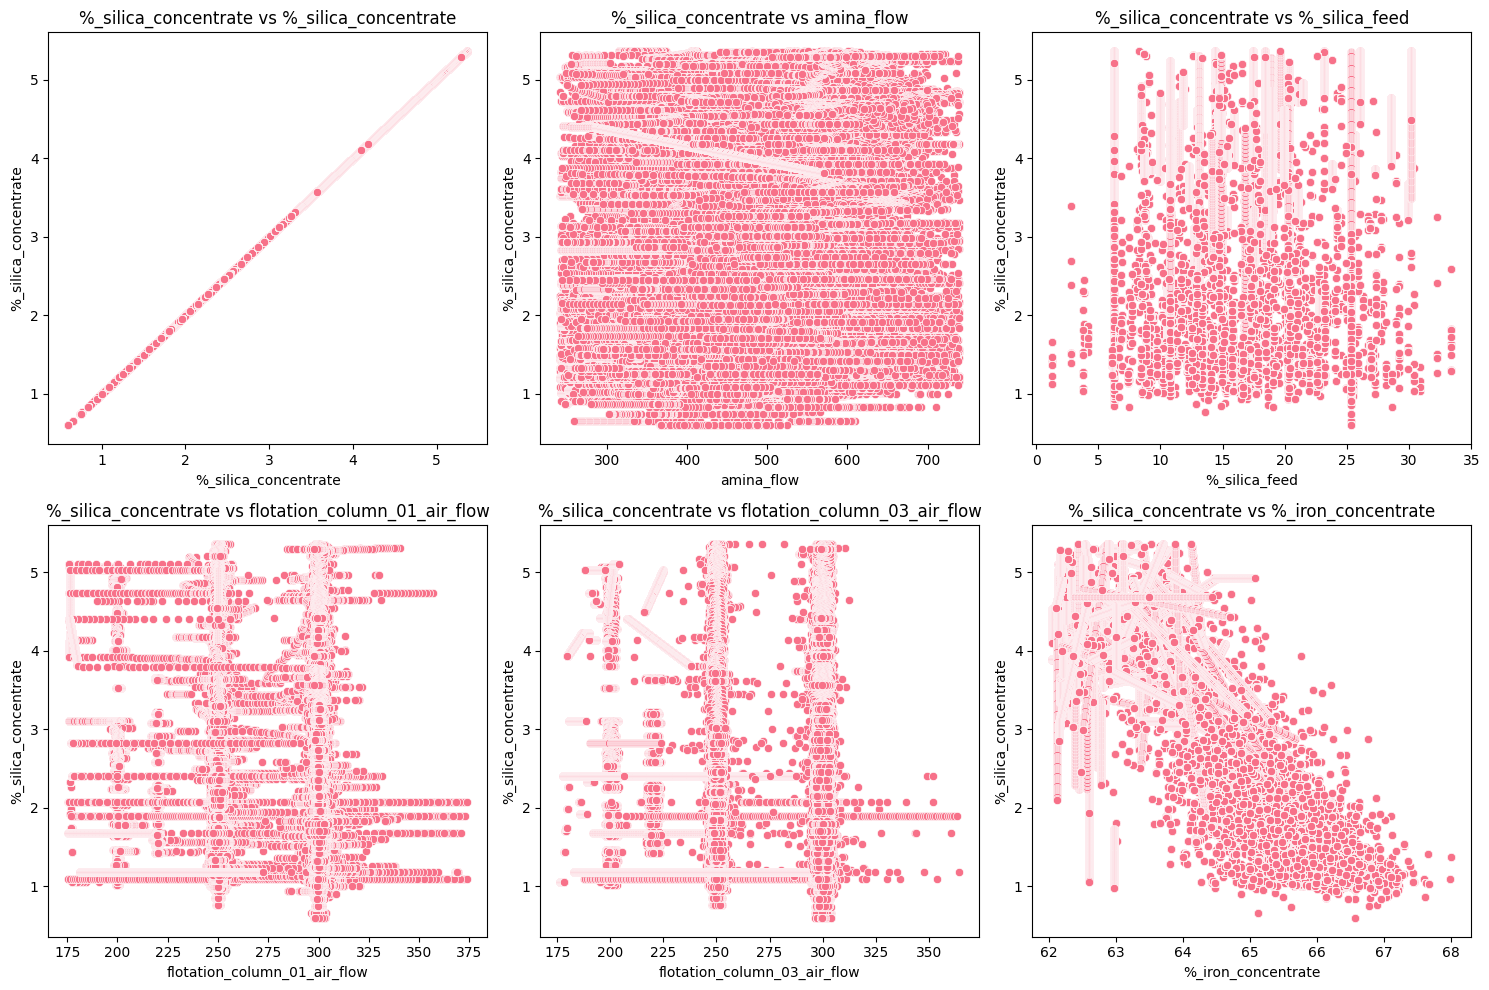

In [29]:
# Calculate correlations with target variable
correlations = df.select_dtypes(include=['number']).corr()[target_column].sort_values(ascending=False)
print("Top correlations with target variable:")
print(correlations.head(10))
print("\nBottom correlations with target variable:")
print(correlations.tail(10))
print("\n")

# Plot correlation heatmap
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            linewidths=0.5, vmax=1, vmin=-1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Identify top correlated features (positive and negative)
high_corr_features = abs(correlations).sort_values(ascending=False).index[1:6]
print(f"Using top correlated features for engineering: {list(high_corr_features)}")

# Visualize relationships between top correlated features and target
top_positive = correlations.head(3).index.tolist()
top_negative = correlations.tail(3).index.tolist()

# Create scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(top_positive):
    sns.scatterplot(x=df[col], y=df[target_column], ax=axes[0, i])
    axes[0, i].set_title(f'{target_column} vs {col}')

for i, col in enumerate(top_negative):
    sns.scatterplot(x=df[col], y=df[target_column], ax=axes[1, i])
    axes[1, i].set_title(f'{target_column} vs {col}')

plt.tight_layout()
plt.show()

In [ ]:
numeric_columns = df.select_dtypes(include=['number']).columns

In [31]:
# Create ratios and interactions between important features
for i, feat1 in enumerate(high_corr_features):
    for feat2 in high_corr_features[i+1:]:
        # Create ratio feature
        ratio_name = f'{feat1}_to_{feat2}_ratio'
        df[ratio_name] = df[feat1] / df[feat2].replace(0, np.nan)
        df[ratio_name] = df[ratio_name].replace([np.inf, -np.inf], np.nan).fillna(df[ratio_name].median())
        
        # Create product feature
        product_name = f'{feat1}_x_{feat2}'
        df[product_name] = df[feat1] * df[feat2]

# Create polynomial features for top correlated variables
for feature in high_corr_features:
    df[f'{feature}_squared'] = df[feature] ** 2

print(f"Dataset shape after feature engineering: {df.shape}")
print(f"New features added: {df.shape[1] - len(numeric_columns)}")

Dataset shape after feature engineering: (731525, 49)
New features added: 26


In [32]:
# Calculate statistical features for air flow columns if they exist
air_flow_cols = [col for col in df.columns if 'air_flow' in col.lower()]
if len(air_flow_cols) > 0:
    df['mean_air_flow'] = df[air_flow_cols].mean(axis=1)
    df['std_air_flow'] = df[air_flow_cols].std(axis=1)
    df['max_min_ratio_air_flow'] = df[air_flow_cols].max(axis=1) / df[air_flow_cols].min(axis=1).replace(0, np.nan)
    df['max_min_ratio_air_flow'] = df['max_min_ratio_air_flow'].replace([np.inf, -np.inf], np.nan).fillna(df['max_min_ratio_air_flow'].median())
    print(f"Created air flow statistical features: mean_air_flow, std_air_flow, max_min_ratio_air_flow")

# Calculate statistical features for level columns if they exist
level_cols = [col for col in df.columns if 'level' in col.lower()]
if len(level_cols) > 0:
    df['mean_level'] = df[level_cols].mean(axis=1)
    df['std_level'] = df[level_cols].std(axis=1)
    df['level_range'] = df[level_cols].max(axis=1) - df[level_cols].min(axis=1)
    print(f"Created level statistical features: mean_level, std_level, level_range")

Created air flow statistical features: mean_air_flow, std_air_flow, max_min_ratio_air_flow
Created level statistical features: mean_level, std_level, level_range


Key Insight(s) tahap Feature Engineering:
- Proses feature engineering berhasil menghasilkan 35 fitur baru yang meningkatkan kapasitas model untuk menangkap hubungan kompleks dalam data.
- Fitur engineering dilakukan dengan pendekatan berbasis korelasi, menggunakan variabel yang memiliki korelasi tertinggi dengan target sebagai dasar pembuatan fitur baru.
- Penggunaan statistik agregasi berbeda antara fitur 'air_flow' dan 'level' didasarkan pada karakteristik intrinsik variabel tersebut:
  - Untuk 'air_flow' digunakan mean, std, dan max_min_ratio karena aliran udara dalam proses flotasi bersifat proporsional dan memiliki efek multiplikatif. Rasio antara nilai maksimum dan minimum sangat penting untuk mendeteksi ketidakseimbangan sistem yang dapat mempengaruhi efisiensi pemisahan mineral.
  - Untuk 'level' digunakan mean, std, dan level_range karena merepresentasikan ketinggian fisik dalam kolom flotasi, di mana perbedaan absolut (range) memiliki interpretasi fisik langsung terhadap variasi ketinggian cairan dalam proses.
- Berdasarkan analisis distribusi pada tahap EDA sebelumnya, variabel air_flow menunjukkan distribusi multimodal yang distingtif, sehingga fitur perbandingan (rasio) lebih informatif, sementara variabel level menunjukkan pola variasi yang lebih terkait dengan jangkauan nilai absolut.
- Feature engineering ini memperkaya dataset dengan informasi tambahan tentang hubungan antar variabel yang tidak terlihat dalam data mentah, memungkinkan model machine learning menangkap pola yang lebih kompleks.

## Data Split Handling

Data dipartisi untuk memungkinkan pelatihan dan evaluasi model yang tepat:
- Fitur (X) dipisahkan dari variabel target (y)
- Kolom non-numerik dihapus
- Nilai yang hilang yang tersisa ditangani untuk berjaga-jaga
- Data dibagi menjadi set pelatihan (80%) dan pengujian (20%)

In [33]:
# Define features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

# Remove any non-numeric columns (like date)
X = X.select_dtypes(include=['number'])

# Final check for any remaining NaN values
X = X.fillna(X.median())

# Split data into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (585220, 53)
Test set size: (146305, 53)


## Feature Scaling

Langkah ini mengubah semua fitur agar memiliki mean nol dan varians satu menggunakan standardisasi sesuai keputusan yang diambil dari hasil EDA

In [34]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframes for better handling (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

## Save Processed Data

In [35]:
import os
import joblib

# Create directory if it doesn't exist
output_dir = '../data/processed'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save processed data
np.save(f'{output_dir}/X_train_scaled.npy', X_train_scaled)
np.save(f'{output_dir}/X_test_scaled.npy', X_test_scaled)
np.save(f'{output_dir}/y_train.npy', y_train.values)
np.save(f'{output_dir}/y_test.npy', y_test.values)

# Save feature names
feature_columns = X_train.columns.tolist()
with open(f'{output_dir}/feature_columns.txt', 'w') as f:
    f.write('\n'.join(feature_columns))

# Save scaler for future use
joblib.dump(scaler, f'{output_dir}/scaler.joblib')

['../data/processed/scaler.joblib']

In [36]:
print("\nData Preparation Summary:")
print("-----------------------")
print(f"Original dataset shape: {df.shape}")
print(f"Features after preprocessing: {X.shape[1]}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nFeature Engineering:")
engineered_features = [col for col in X.columns if ('_to_' in col or '_x_' in col or '_squared' in col or
                                                   'mean_' in col or 'std_' in col or '_range' in col)]
print(f"- Created {len(engineered_features)} engineered features")
print("- Types of engineered features:")
print("  - Ratio features between highly correlated variables")
print("  - Interaction (product) features")
print("  - Polynomial features (squared terms)")
print("  - Statistical aggregations (mean, std, range) for similar sensors")

print("\nPrepared data saved to:", output_dir)


Data Preparation Summary:
-----------------------
Original dataset shape: (731525, 55)
Features after preprocessing: 53
Training set: 585220 samples
Test set: 146305 samples

Feature Engineering:
- Created 30 engineered features
- Types of engineered features:
  - Ratio features between highly correlated variables
  - Interaction (product) features
  - Polynomial features (squared terms)
  - Statistical aggregations (mean, std, range) for similar sensors

Prepared data saved to: ../data/processed


# Checklist Revisi Submission
- [ ] Tambahkan penjelasan di setiap tahapan proyek menggunakan text cell (Markdown). Jelaskan proses yang dilakukan dan hasil dari proses tersebut.
    - [x] Pada notebook 01_EDA.ipynb
    - [x] Pada notebook 02_data_preparation.ipynb
    - [ ] Pada notebook 03_model.ipynb
- [ ] Gunakan bahasa Indonesia dalam penulisan laporan.
- [x] Jelaskan seluruh tahap preprocessing secara urut.
  - [x] Contoh: `drop_duplicates`
  - [x] Contoh: parsing kolom tanggal (`parse date column`)|
- [ ] Jelaskan cara kerja masing-masing algoritma/model yang digunakan.
- [ ] Gunakan heading markdown untuk struktur yang rapi pada penjelasan model:
  - `## Modeling`
  - `### Model 1`, `### Model 2`, dst.
- [ ] Jelaskan setiap parameter yang digunakan pada model.
- [ ] Tambahkan kelebihan dan kekurangan model.
- [ ] Perlihatkan hasil evaluasi baseline model.
- [ ] Pindahkan hasil baseline model dari bagian modelling ke bagian evaluasi.
- [ ] Tambahkan kesimpulan dari problem statement di akhir tahap evaluasi.